## **Cleaning and Target Engineering**

## Objective

This notebook prepares the FinAccess survey dataset for trustworthy machine learning modeling.

The notebook focuses on:
- data cleaning
- leakage-aware target engineering
- safe predictor selection
- missing-value governance
- structural feature engineering
- reproducible preprocessing

A major focus of this notebook is preventing target leakage caused by engineered financial-access variables already present in the survey system.

The goal is to prepare a modeling dataset that:
- supports explainable AI
- reflects realistic deployment conditions
- prioritizes structural exclusion risk rather than direct financial outcome indicators

## Environment Setup & Reproducibility Configuration

This section initializes:
- required libraries
- project paths
- artifact directories
- figure-saving infrastructure

The goal is to ensure that:
- outputs are reproducible
- charts are automatically saved
- processed datasets can be reused
- project artifacts remain organized

In [73]:
#Import Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from pathlib import Path

## Figure Saving Configuration

All important charts generated throughout the project are saved to the reports/figures directory to improve:
- reproducibility
- reporting
- stakeholder communication
- portfolio presentation quality

In [4]:
BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "Data" / "Raw" / "finaccess_2021_microdata.xlsx"
PROCESSED_DIR = BASE_DIR / "Data" / "Processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "metrics"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Data Loading & Initial Validation

The FinAccess respondent-level dataset is loaded and validated before preprocessing begins.

This section verifies:
- dataset accessibility
- structural integrity
- expected dimensions
- target-source availability

Early validation is important because preprocessing pipelines depend on:
- consistent schema structure
- stable variable naming
- reliable target definitions

In [5]:
df = pd.read_excel(RAW_DATA_PATH, sheet_name="Dataset")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 22024
Columns: 2332


## Dataset Validation Observations

The dataset loaded successfully and contains:
- 22,024 respondent records
- 2,332 variables

This confirms that the notebook is operating on the full respondent-level FinAccess survey dataset.

The high dimensionality of the dataset reinforces the need for:
- feature governance
- leakage auditing
- dimensionality reduction
- systematic preprocessing

# Target Source Validation

Before engineering the machine learning target variable, the original survey variable responsible for financial inclusion classification is inspected.

This validation step ensures:
- the target source exists
- category labels are interpretable
- target engineering assumptions are valid

Careful target validation is critical because the quality of the target variable directly determines:
- modeling trustworthiness
- evaluation validity
- deployment realism

In [45]:
# Proposed target source variable

target_source_col = "excluded_informal_banked2022"

# Validate target source existence

target_source_col in df.columns

True

In [46]:
# Inspect target source categories

df[target_source_col].value_counts(dropna=False)

excluded_informal_banked2022
Banked          15108
Excluded         4594
Other Formal     2322
Name: count, dtype: int64

## Target Source Observations

The proposed target source variable contains multiple financial inclusion categories, including:
- Banked
- Excluded
- Other Formal

This confirms that the survey already contains engineered financial inclusion classifications.

The target engineering process must therefore carefully transform these categories into a modeling target while preventing:
- leakage
- target ambiguity
- unrealistic deployment assumptions

# Leakage-Safe Target Engineering

The original survey variable contains multiple financial inclusion categories representing different levels of formal and informal financial access.

To support interpretable and policy-oriented machine learning modeling, the target is transformed into a binary exclusion-risk outcome.

The new target variable:
- identifies financially excluded respondents
- separates excluded vs non-excluded populations
- supports explainable classification modeling

This approach aligns with the project objective of identifying structural financial vulnerability rather than reproducing complex financial-category taxonomies.

In [47]:
# Create binary financial exclusion target

df["financially_excluded"] = np.where(
    df[target_source_col] == "Excluded",
    1,
    0
)

# Target Integrity Validation

After target engineering, the target distribution is validated to ensure:
- categories were mapped correctly
- no unexpected values remain
- class structure is interpretable

Target validation is important because incorrect target engineering can invalidate:
- machine learning evaluation
- stakeholder conclusions
- deployment decisions

In [48]:
# Validate target distribution

df["financially_excluded"].value_counts()

financially_excluded
0    17430
1     4594
Name: count, dtype: int64

## Target Distribution Observations

The engineered target variable successfully separates:
- financially excluded respondents
- non-excluded respondents

The distribution indicates that financially excluded respondents represent a minority portion of the population.

This creates a class imbalance problem, meaning that evaluation metrics such as:
- recall
- precision
- F1-score
- ROC-AUC

will become more important than raw accuracy during modeling.

# Target Distribution Visualization

The class distribution is visualized to better understand:
- imbalance severity
- exclusion prevalence
- modeling complexity

Class imbalance is important because highly imbalanced datasets can produce misleading accuracy scores if not evaluated carefully.

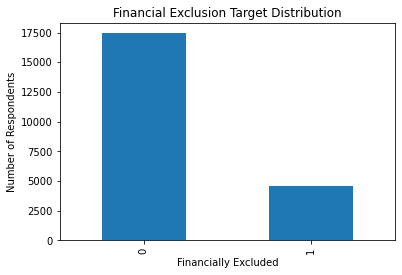

<Figure size 432x288 with 0 Axes>

In [92]:
plt.figure(figsize=(6,4))

df["financially_excluded"].value_counts().plot(kind="bar")

plt.title("Financial Exclusion Target Distribution")
plt.xlabel("Financially Excluded")
plt.ylabel("Number of Respondents")
plt.show()

plt.savefig(
    FIGURES_DIR / "02_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)



## Target Distribution Interpretation

The target visualization confirms that the dataset contains a class imbalance problem where financially excluded respondents represent a minority population.

However, the excluded class remains sufficiently represented to support:
- supervised machine learning
- subgroup analysis
- explainability workflows

The imbalance reinforces the importance of evaluation metrics beyond accuracy, including:
- recall
- precision
- F1-score
- ROC-AUC

From a policy perspective, correctly identifying financially excluded individuals is likely more important than maximizing overall accuracy because exclusion cases represent the primary intervention population.

In [50]:
target_distribution.to_csv(
    ARTIFACTS_DIR / "02_target_distribution.csv",
    index=False
)

The target is imbalanced. Financially excluded respondents are the minority class.

This means accuracy alone will not be enough during modeling. Later notebooks should prioritize recall, precision, F1-score, ROC-AUC, and confusion matrix interpretation.

# Leakage Variable Governance

The FinAccess survey contains many engineered financial-access indicators that may directly or indirectly encode the target outcome.

To maintain:
- trustworthy modeling
- explainability integrity
- deployment realism

high-risk leakage variables must be identified and excluded before modeling.

The goal is to ensure that the machine learning system learns:
- structural exclusion risk
rather than:
- existing financial-access outcomes

## High-Risk Leakage Variables

Variables that directly summarize:
- financial access
- exclusion status
- formal banking participation
- financial service usage

are categorized as high-risk leakage variables.

These variables are unsuitable for predictive modeling because they already contain information closely related to the target outcome.

In [51]:
# High-risk leakage variables

high_risk_leakage = [
    
    # Direct exclusion/access indicators
    "formal",
    "formal_ever",
    "accessformal",
    "excludedpop_ever",
    
    # Financial participation summaries
    "formal_service_use",
    "formal_fullservice_use",
    
    # Savings and loan outcomes
    "savings_usage",
    "loan_usage",
    
    # Insurance outcomes
    "insurance_usage",
    "insurance_usage1",
    "insurance_usage2",
    
    # Original target source
    target_source_col
]

high_risk_leakage

['formal',
 'formal_ever',
 'accessformal',
 'excludedpop_ever',
 'formal_service_use',
 'formal_fullservice_use',
 'savings_usage',
 'loan_usage',
 'insurance_usage',
 'insurance_usage1',
 'insurance_usage2',
 'excluded_informal_banked2022']

## Leakage Governance Observations

The identified high-risk variables directly summarize:
- financial access status
- formal participation
- exclusion outcomes
- financial service usage

These variables are excluded from modeling governance because they already encode information closely related to the target outcome.

Retaining such variables would likely produce:
- unrealistic model performance
- misleading evaluation metrics
- poor deployment generalization
- distorted explainability results

## Moderate-Risk Financial Variables

Some financial-behavior variables may contain:
- indirect vulnerability signals
- contextual financial behavior
- socioeconomic risk indicators

These variables require additional evaluation because they may provide useful structural information without directly encoding the target outcome.

In [52]:
# Moderate-risk variables

moderate_risk_variables = [
    "Digital_credit",
    "digital_app_loan",
    "currentloan",
    "defaultloan",
    "credit_Inst",
    "tot_saving",
    "noofloans"
]

moderate_risk_variables

['Digital_credit',
 'digital_app_loan',
 'currentloan',
 'defaultloan',
 'credit_Inst',
 'tot_saving',
 'noofloans']

# Create Leakage-Safe Modeling Dataset

A modeling dataset is now constructed by removing:
- high-risk leakage variables
- administrative identifiers
- direct target-source variables

The resulting dataset is intended to support:
- trustworthy machine learning
- explainable AI analysis
- realistic deployment conditions
- policy-oriented interpretation

## Administrative Variables

Administrative and identifier variables are excluded because they:
- represent operational survey tracking
- contain little behavioral meaning
- increase overfitting risk
- reduce explainability

In [53]:
# Administrative variables

admin_variables = [
    "Serial Number",
    "interview__key",
    "interview__id"
]

admin_variables

['Serial Number', 'interview__key', 'interview__id']

## Combined Governance Exclusion List

The governance exclusion list combines:
- high-risk leakage variables
- administrative identifiers

This unified exclusion framework supports:
- preprocessing consistency
- reproducibility
- trustworthy modeling governance

In [54]:
# Combined exclusion list

exclude_cols = (
    high_risk_leakage
    + admin_variables
)

len(exclude_cols)

15

# Construct Modeling Dataframe

The leakage-safe modeling dataframe is created by excluding governance-restricted variables while retaining potentially useful structural predictors.

This dataframe becomes the primary analytical dataset for:
- exploratory analysis
- preprocessing
- machine learning
- explainability
- fairness analysis

In [55]:
# Create leakage-safe modeling dataset

model_df = df.drop(
    columns=exclude_cols,
    errors="ignore"
)

print("Modeling Dataset Shape:")
print(model_df.shape)

Modeling Dataset Shape:
(22024, 2318)


## Modeling Dataset Construction Observations

The governance filtering process successfully removed:
- high-risk leakage variables
- administrative identifiers
- direct target-source variables

while preserving all respondent records.

The resulting modeling dataset contains:
- 22,024 respondent observations
- 2,318 candidate predictor variables

Although unsafe variables were removed, the dataset remains highly dimensional, reinforcing the need for:
- sparse-variable filtering
- feature governance
- dimensionality reduction
- systematic preprocessing

# Missingness Governance & Sparse Variable Filtering

The leakage-safe modeling dataset still contains thousands of variables, many of which may contain substantial structural sparsity.

This section evaluates:
- missing-value severity
- feature usability
- sparse-variable prevalence

The goal is to reduce:
- preprocessing complexity
- dimensionality burden
- explainability noise

while retaining structurally meaningful predictors.

## Modeling Dataset Missingness Audit

Missingness is recalculated after governance filtering to understand:
- remaining sparsity levels
- feature usability
- preprocessing burden

This audit helps identify variables that may contribute limited analytical value due to extreme missingness.

In [58]:
# Missingness percentage in modeling dataset

model_missing_pct = (
    model_df.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

model_missing_pct

E1vSi                     100.0
H4.10                     100.0
U4i                       100.0
E1viJi                    100.0
P16i                      100.0
                          ...  
Commercial_Bank_users       0.0
Traditional_bank_users      0.0
filt                        0.0
non_dts                     0.0
financially_excluded        0.0
Length: 2318, dtype: float64

In [59]:
model_missing_pct.to_csv(
    ARTIFACTS_DIR / "02_model_missingness_audit.csv"
)

## Sparse Variable Governance Threshold

A missingness threshold is defined to identify variables with extremely limited usable information.

Variables with very high missingness:
- contribute limited analytical value
- increase preprocessing complexity
- worsen explainability
- increase dimensionality unnecessarily

The threshold-based approach improves:
- reproducibility
- governance transparency
- preprocessing consistency

In [60]:
# Sparse-variable threshold

missingness_threshold = 90

# Identify highly sparse variables

high_missing_cols = model_missing_pct[
    model_missing_pct > missingness_threshold
].index.tolist()

print("Number of variables above threshold:")
print(len(high_missing_cols))

Number of variables above threshold:
792


In [61]:
# Preview highly sparse variables

high_missing_cols[:20]

['E1vSi',
 'H4.10',
 'U4i',
 'E1viJi',
 'P16i',
 'H4.11',
 'P15i',
 'H4.32',
 'H4.13',
 'H4.3',
 'E1viLi',
 'H4.1',
 'E1iiiMi',
 'E1vMi',
 'B3Di.4',
 'H3.99',
 'E1iiiQi',
 'H4.4',
 'H4.21',
 'E1viNi']

## Sparse Variable Audit Observations

The missingness audit identified 792 variables with more than 90% missing values.

This means that approximately one-third of the remaining modeling variables contain extremely limited usable information.

The highly sparse variables appear to consist primarily of:
- encoded survey branch variables
- conditional-response indicators
- subgroup-specific questionnaire fields

This reinforces earlier findings that the FinAccess survey relies heavily on:
- branching questionnaire logic
- conditional survey pathways
- subgroup-targeted financial modules

From a machine learning perspective, retaining highly sparse variables may:
- increase dimensionality unnecessarily
- worsen preprocessing complexity
- reduce explainability quality
- increase computational burden

# Remove Highly Sparse Variables

Variables exceeding the sparse-feature threshold are removed from the modeling dataset.

This filtering step aims to:
- improve feature usability
- reduce dimensionality
- simplify preprocessing
- improve explainability
- reduce computational burden

The filtering process is governance-driven and reproducible through the predefined missingness threshold.

In [62]:
# Remove highly sparse variables

model_df = model_df.drop(
    columns=high_missing_cols,
    errors="ignore"
)

print("Updated Modeling Dataset Shape:")
print(model_df.shape)

Updated Modeling Dataset Shape:
(22024, 1526)


## Sparse Variable Filtering Interpretation

After removing highly sparse variables, the modeling dataset was reduced from:
- 2,318 variables
to:
- 1,526 variables

This represents a substantial dimensionality reduction while preserving all respondent records.

The reduction improves:
- preprocessing efficiency
- explainability quality
- feature usability
- computational efficiency
- deployment realism

Importantly, the filtering process was governance-driven rather than arbitrary, relying on a predefined missingness threshold to ensure reproducibility and transparency.

# Structural Feature Engineering

Interpretable structural features are engineered to better capture:
- demographic vulnerability
- geographic disadvantage
- socioeconomic risk patterns

The feature engineering strategy prioritizes:
- explainability
- stakeholder relevance
- policy interpretability
- deployment realism

Rather than creating highly complex transformations, the notebook focuses on simple interpretable indicators that can later support:
- explainable AI analysis
- subgroup vulnerability assessment
- policy-oriented recommendations

## Youth Vulnerability Indicator

A youth vulnerability indicator is engineered to identify younger respondents who may face:
- unstable income
- employment barriers
- reduced formal financial access

Youth populations are often important in financial inclusion research because they may experience structural barriers to formal participation.

In [70]:
# Youth indicator

model_df["is_youth"] = np.where(
    model_df["A19"] < 35,
    1,
    0
)

model_df["is_youth"].value_counts()

is_youth
0    11313
1    10711
Name: count, dtype: int64

## Youth Feature Observations

The engineered youth indicator reveals that the survey population is relatively balanced between:
- younger respondents
- older respondents

This is beneficial for downstream modeling because:
- subgroup analysis becomes more reliable
- demographic comparisons become more stable
- explainability workflows can better evaluate age-related vulnerability patterns

From a policy perspective, youth populations may experience:
- employment instability
- lower formal financial participation
- reduced access to credit
- digital-finance dependency

This makes youth-related structural analysis important for financial inclusion intelligence.

## Youth Population Distribution

The youth indicator distribution is visualized to better understand:
- subgroup balance
- demographic composition
- potential policy relevance

Balanced subgroup representation improves:
- modeling reliability
- subgroup explainability
- fairness analysis

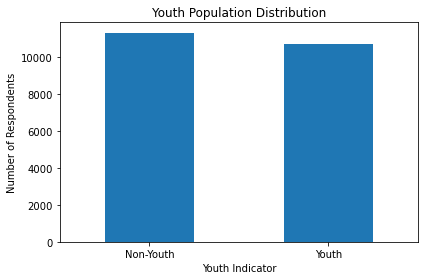

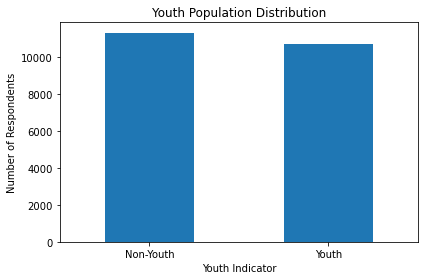

In [80]:
fig, ax = plt.subplots(figsize=(6, 4))

model_df["is_youth"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Youth Population Distribution")
ax.set_xlabel("Youth Indicator")
ax.set_ylabel("Number of Respondents")

ax.set_xticklabels(["Non-Youth", "Youth"], rotation=0)

fig.tight_layout()

display(fig)

fig.savefig(
    FIGURES_DIR / "02_youth_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Rural Vulnerability Features

Geographic conditions may strongly influence financial inclusion outcomes.

Rural populations can experience:
- reduced financial infrastructure
- lower banking access
- transportation limitations
- weaker digital connectivity

This section engineers interpretable geographic indicators to support:
- exclusion-risk analysis
- subgroup vulnerability assessment
- explainable AI interpretation
- policy-oriented recommendations

## Settlement-Type Validation

The settlement-type variable is inspected before feature engineering to:
- validate category consistency
- detect missing values
- confirm rural/urban labeling structure

Validation helps ensure that engineered geographic indicators remain reliable and interpretable.

In [82]:
# Inspect settlement categories

model_df["A9"].value_counts(dropna=False)

A9
Rural    14455
Urban     7569
Name: count, dtype: int64

## Settlement-Type Observations

The survey population is predominantly rural, with rural respondents representing the majority of observations.

This is important because rural populations may experience:
- reduced access to formal financial institutions
- weaker infrastructure
- transportation limitations
- reduced digital connectivity

The strong rural representation supports:
- subgroup vulnerability analysis
- geographic fairness evaluation
- policy-oriented financial inclusion analysis

## Rural Indicator Engineering

A binary rural indicator is engineered to simplify:
- subgroup analysis
- explainability interpretation
- modeling workflows

The feature captures whether a respondent belongs to a rural settlement category.

In [83]:
# Create rural indicator

model_df["is_rural"] = np.where(
    model_df["A9"] == "Rural",
    1,
    0
)

model_df["is_rural"].value_counts()

is_rural
1    14455
0     7569
Name: count, dtype: int64

## Rural Indicator Observations

The engineered rural indicator successfully captures settlement structure while simplifying downstream modeling workflows.

The feature preserves the strong rural representation observed in the survey population.

From a financial inclusion perspective, rural populations may experience:
- reduced access to banking infrastructure
- transportation limitations
- weaker digital connectivity
- reduced exposure to formal financial systems

The feature is highly interpretable and may later become important for:
- SHAP explainability
- subgroup fairness analysis
- geographic vulnerability assessment

## Rural-Youth Interaction Feature

An interaction feature combining:
- youth vulnerability
and
- rural vulnerability

is engineered to help identify respondents potentially exposed to compounded structural disadvantage.

This feature may later support:
- subgroup explainability
- vulnerability segmentation
- policy-oriented targeting

In [84]:
# Rural-youth interaction feature

model_df["rural_youth"] = np.where(
    (model_df["is_rural"] == 1) &
    (model_df["is_youth"] == 1),
    1,
    0
)

model_df["rural_youth"].value_counts()

rural_youth
0    15757
1     6267
Name: count, dtype: int64

## Rural-Youth Interaction Observations

The engineered interaction feature identifies respondents who simultaneously belong to:
- rural populations
and
- youth populations

This subgroup represents a substantial portion of the survey population.

The interaction feature may later support:
- subgroup explainability
- vulnerability segmentation
- policy-oriented intervention analysis

From a structural-risk perspective, rural youth populations may experience compounded disadvantage due to:
- employment instability
- infrastructure limitations
- reduced institutional access
- weaker formal financial exposure

# Stakeholder-Readable Column Naming

Raw survey variable names such as `A9`, `A10i`, `A19`, `A21`, and `A22` are difficult to interpret in downstream notebooks.

Before saving the final modeling dataset, selected structural variables are renamed into stakeholder-readable names.

This improves:
- EDA readability
- modeling interpretation
- SHAP explainability
- stakeholder communication

In [93]:
rename_map = {
    "A9": "location_type",
    "A10i": "gender",
    "A19": "raw_age",
    "A21": "education_level",
    "A22": "marital_status"
}

rename_map = {
    old: new
    for old, new in rename_map.items()
    if old in model_df.columns
}

model_df = model_df.rename(columns=rename_map)

model_df.head()

,County,ClusterNo,HHNo,location_type,A9i,gender,A14v,A14vi,A15,A17,...,formal_banked2022,NHIF_health_insurance,NHIF_ONLY,Nomedical,NHIFMedical_Cat,adults,financially_excluded,is_youth,is_rural,rural_youth
0,Trans Nzoia,10226038,1048,Rural,Access granted,Female,1,1,Swahili,0,...,No,Yes,NaN,NaN,Users of NHIF + medical insurance (C1_42 and C...,1 adult Household,0,0,1,0
1,Busia,10240034,1080,Rural,Access granted,Female,4,2,English,0,...,Yes,Yes,1.0,NaN,"Users of NHIF only, with no medical insurance",>1 adult Household,0,0,1,0
2,Machakos,10216062,1013,Rural,Access granted,Male,1,1,Swahili,0,...,No,Yes,1.0,NaN,"Users of NHIF only, with no medical insurance",1 adult Household,1,0,1,0
3,Kisumu,10242078,1026,Rural,Access granted,Male,5,4,Swahili,0,...,Yes,No,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household,0,1,1,1
4,Nyeri,10219138,1019,Urban,Access granted,Male,3,2,Other(specify),0,...,Yes,No,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household,0,0,0,0


# Final Cleaning Validation & Artifact Saving

The final preprocessing outputs are validated and saved to support:
- reproducibility
- downstream analysis
- modeling consistency
- deployment readiness

The notebook saves:
- the cleaned modeling dataset
- preprocessing metadata
- governance artifacts
- feature inventories

This ensures that future notebooks operate on consistent governed data rather than recreating preprocessing logic repeatedly.

## Final Dataset Validation

The final modeling dataset is validated before export to ensure:
- preprocessing completed successfully
- target availability remains intact
- engineered features exist
- dimensionality reduction behaved as expected

In [94]:
# Final dataset validation

print("Final Dataset Shape:")
print(model_df.shape)

print("\nTarget Distribution:")
print(model_df["financially_excluded"].value_counts())

print("\nEngineered Features:")
print([
    "is_youth",
    "is_rural",
    "rural_youth"
])

Final Dataset Shape:
(22024, 1529)

Target Distribution:
financially_excluded
0    17430
1     4594
Name: count, dtype: int64

Engineered Features:
['is_youth', 'is_rural', 'rural_youth']


## Final Validation Observations

The final modeling dataset successfully preserves:
- all respondent observations
- the engineered target variable
- interpretable structural features

while substantially reducing dimensionality through:
- leakage governance
- sparse-variable filtering
- administrative-variable exclusion

The resulting dataset now provides a stronger foundation for:
- exploratory analysis
- explainable machine learning
- fairness analysis
- deployment-oriented modeling

## Save Cleaned Modeling Dataset

The cleaned and governance-filtered modeling dataset is saved for downstream notebooks.

Saving processed artifacts improves:
- reproducibility
- workflow modularity
- deployment consistency
- collaboration efficiency

In [95]:
# Save cleaned modeling dataset

model_df.to_csv(
    PROCESSED_DIR / "financial_inclusion_model_df.csv",
    index=False
)

print("Cleaned modeling dataset saved successfully.")

Cleaned modeling dataset saved successfully.


## Save Governance Artifacts

Important preprocessing metadata and governance artifacts are saved to support:
- reproducibility
- explainability
- governance auditing
- downstream consistency

In [96]:
# Save feature inventory

feature_columns = model_df.columns.tolist()

with open(
    ARTIFACTS_DIR / "02_feature_columns.json",
    "w"
) as f:
    json.dump(feature_columns, f, indent=4)

print("Feature inventory saved.")

Feature inventory saved.


In [97]:
# Save sparse-variable audit

with open(
    ARTIFACTS_DIR / "02_removed_sparse_columns.json",
    "w"
) as f:
    json.dump(high_missing_cols, f, indent=4)

print("Sparse-variable audit saved.")

Sparse-variable audit saved.


In [98]:
# Save leakage-governance audit

with open(
    ARTIFACTS_DIR / "02_high_risk_leakage_variables.json",
    "w"
) as f:
    json.dump(high_risk_leakage, f, indent=4)

print("Leakage-governance audit saved.")

Leakage-governance audit saved.


# Summary

This notebook transformed the raw FinAccess survey into a governance-oriented modeling dataset.

Major preprocessing activities included:
- leakage-safe target engineering
- governance-based variable exclusion
- sparse-variable filtering
- structural feature engineering
- reproducible artifact creation

Key achievements include:
- prevention of major target leakage risks
- dimensionality reduction from 2,332 to 1,529 variables
- creation of interpretable structural vulnerability features
- preservation of all respondent observations
- establishment of reproducible preprocessing infrastructure

The notebook established a trustworthy analytical foundation for:
- exploratory analysis
- explainable machine learning
- fairness evaluation
- deployment-oriented financial exclusion modeling

The next notebook will focus on:
- exploratory data analysis
- subgroup vulnerability analysis
- exclusion pattern discovery
- policy-oriented insight generation